# Experiment 1: Working with Python Packages — NumPy, Pandas, SciPy, Scikit-learn, Matplotlib

**Course:** ICS1512 — Machine Learning Algorithms Laboratory
**Institution:** Sri Sivasubramaniya Nadar College of Engineering, Chennai
**Degree & Branch:** M.Tech (Integrated) Computer Science & Engineering, Semester V

**Aim:** To explore core functions of NumPy, Pandas, SciPy, Scikit-learn and Matplotlib, and to apply the
machine learning workflow (EDA, preprocessing, feature selection, data splitting, evaluation) on five
benchmark datasets, identifying the appropriate ML task and algorithm for each.

> **Note on datasets:** This environment does not have open internet access to Kaggle/UCI, so the
> Iris, Diabetes and Handwritten-digit datasets are loaded via **scikit-learn's built-in loaders**
> (identical data to the UCI originals). The **Loan Amount Prediction** and **Email Spam** datasets
> are not bundled with scikit-learn, so realistic **synthetic datasets** (same feature structure as the
> Kaggle versions) are generated in code — replace the loading cell with
> `pd.read_csv("loan_data.csv")` / `pd.read_csv("spam.csv")` if you have downloaded the real files
> from Kaggle/UCI.


In [1]:
# 0. Setup — install/import all required libraries
# !pip install numpy pandas scipy scikit-learn matplotlib seaborn   # uncomment if not already installed

import numpy as np
import pandas as pd
import scipy
from scipy import stats
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("SciPy       :", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib  :", matplotlib.__version__)

%matplotlib inline
sns.set_style("whitegrid")

NumPy       : 2.4.4
Pandas      : 3.0.2
SciPy       : 1.17.1
Scikit-learn: 1.8.0
Matplotlib  : 3.10.8


## Part 1 — NumPy: Array Manipulation & Numerical Computing

In [2]:
# 1.1 Array creation
a = np.array([1, 2, 3, 4, 5])
zeros = np.zeros((2, 3))
ones = np.ones((3, 3))
arange_arr = np.arange(0, 10, 2)
lin_arr = np.linspace(0, 1, 5)
identity = np.eye(3)

print("a          :", a)
print("zeros      :\n", zeros)
print("ones       :\n", ones)
print("arange     :", arange_arr)
print("linspace   :", lin_arr)
print("identity   :\n", identity)

a          : [1 2 3 4 5]
zeros      :
 [[0. 0. 0.]
 [0. 0. 0.]]
ones       :
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
arange     : [0 2 4 6 8]
linspace   : [0.   0.25 0.5  0.75 1.  ]
identity   :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [3]:
# 1.2 Array attributes, indexing, slicing, reshaping
print("Shape:", a.shape, "| Ndim:", a.ndim, "| Dtype:", a.dtype)
print("First 3:", a[:3], "| Reversed:", a[::-1])

mat = np.arange(12).reshape(3, 4)
print("Reshaped 3x4:\n", mat)
print("Row 1:", mat[1, :], "| Column 2:", mat[:, 2])

Shape: (5,) | Ndim: 1 | Dtype: int64
First 3: [1 2 3] | Reversed: [5 4 3 2 1]
Reshaped 3x4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Row 1: [4 5 6 7] | Column 2: [ 2  6 10]


In [4]:
# 1.3 Mathematical / statistical operations
print("Sum:", a.sum(), "| Mean:", a.mean(), "| Std:", a.std(), "| Var:", a.var())
print("Max/Min:", a.max(), a.min(), "| Argmax/Argmin:", a.argmax(), a.argmin())
print("Cumulative sum:", a.cumsum())

# Element-wise & broadcasting
print("a * 2       :", a * 2)
print("a + [10..50]:", a + np.array([10, 20, 30, 40, 50]))

# Matrix operations
m1 = np.array([[1, 2], [3, 4]])
m2 = np.array([[5, 6], [7, 8]])
print("Matrix product:\n", np.dot(m1, m2))
print("Transpose:\n", m1.T)
print("Determinant:", np.linalg.det(m1))
print("Inverse:\n", np.linalg.inv(m1))

Sum: 15 | Mean: 3.0 | Std: 1.4142135623730951 | Var: 2.0
Max/Min: 5 1 | Argmax/Argmin: 4 0
Cumulative sum: [ 1  3  6 10 15]
a * 2       : [ 2  4  6  8 10]
a + [10..50]: [11 22 33 44 55]
Matrix product:
 [[19 22]
 [43 50]]
Transpose:
 [[1 3]
 [2 4]]
Determinant: -2.0000000000000004
Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [5]:
# 1.4 Boolean masking, sorting, random numbers
mask = a > 2
print("Elements > 2:", a[mask])
print("Sorted (desc):", np.sort(a)[::-1])

rng = np.random.default_rng(42)
rand_arr = rng.random((3, 3))
print("Random 3x3 array:\n", rand_arr)

Elements > 2: [3 4 5]
Sorted (desc): [5 4 3 2 1]
Random 3x3 array:
 [[0.77395605 0.43887844 0.85859792]
 [0.69736803 0.09417735 0.97562235]
 [0.7611397  0.78606431 0.12811363]]


## Part 2 — Pandas: Data Handling

In [6]:
# 2.1 Series and DataFrame creation
s = pd.Series([10, 20, 30, 40], index=["a", "b", "c", "d"])
print("Series:\n", s)

df = pd.DataFrame({
    "Name": ["Asha", "Ravi", "Meera", "Kabir"],
    "Age": [21, 22, 20, 23],
    "Marks": [88, 76, 95, 67]
})
print("\nDataFrame:\n", df)

Series:
 a    10
b    20
c    30
d    40
dtype: int64

DataFrame:
     Name  Age  Marks
0   Asha   21     88
1   Ravi   22     76
2  Meera   20     95
3  Kabir   23     67


In [7]:
# 2.2 Inspecting & selecting data
print(df.info())
print("\n", df.describe())
print("\nColumn 'Age':\n", df["Age"])
print("\nRows where Marks > 80:\n", df[df["Marks"] > 80])

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    4 non-null      str  
 1   Age     4 non-null      int64
 2   Marks   4 non-null      int64
dtypes: int64(2), str(1)
memory usage: 228.0 bytes
None

              Age    Marks
count   4.000000   4.0000
mean   21.500000  81.5000
std     1.290994  12.4499
min    20.000000  67.0000
25%    20.750000  73.7500
50%    21.500000  82.0000
75%    22.250000  89.7500
max    23.000000  95.0000

Column 'Age':
 0    21
1    22
2    20
3    23
Name: Age, dtype: int64

Rows where Marks > 80:
     Name  Age  Marks
0   Asha   21     88
2  Meera   20     95


In [8]:
# 2.3 Handling missing data, grouping, merging
df2 = df.copy()
df2.loc[1, "Marks"] = np.nan
print("With missing value:\n", df2)
print("\nAfter fillna(mean):\n", df2.fillna(df2["Marks"].mean()))

print("\nGroup by pass/fail:")
df["Result"] = np.where(df["Marks"] >= 80, "Pass", "Fail")
print(df.groupby("Result")["Marks"].mean())

With missing value:
     Name  Age  Marks
0   Asha   21   88.0
1   Ravi   22    NaN
2  Meera   20   95.0
3  Kabir   23   67.0

After fillna(mean):
     Name  Age      Marks
0   Asha   21  88.000000
1   Ravi   22  83.333333
2  Meera   20  95.000000
3  Kabir   23  67.000000

Group by pass/fail:
Result
Fail    71.5
Pass    91.5
Name: Marks, dtype: float64


## Part 3 — SciPy: Scientific & Statistical Computing

In [9]:
# 3.1 Descriptive statistics
data = np.array([12, 15, 14, 10, 18, 20, 22, 14, 15, 16])
print("Mean:", np.mean(data), "| Median:", np.median(data))
print("Mode:", stats.mode(data, keepdims=True))
print("Skewness:", stats.skew(data), "| Kurtosis:", stats.kurtosis(data))

# 3.2 Hypothesis testing — one-sample t-test
t_stat, p_val = stats.ttest_1samp(data, popmean=15)
print(f"\nOne-sample t-test vs mean=15: t={t_stat:.3f}, p={p_val:.3f}")

Mean: 15.6 | Median: 15.0
Mode: ModeResult(mode=array([14]), count=array([2]))
Skewness: 0.32815694566595727 | Kurtosis: -0.6009140184929325

One-sample t-test vs mean=15: t=0.528, p=0.611


In [10]:
# 3.3 Special functions & linear algebra
from scipy import special, linalg

print("Gamma(5):", special.gamma(5))
print("Factorial(5) via special.factorial:", special.factorial(5))

A = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
x = linalg.solve(A, b)
print("\nSolution of Ax=b:", x)
print("Eigenvalues of A:", linalg.eigvals(A))

Gamma(5): 24.0
Factorial(5) via special.factorial: 120.0

Solution of Ax=b: [2. 3.]
Eigenvalues of A: [3.61803399+0.j 1.38196601+0.j]


## Part 4 — Matplotlib: Data Visualization

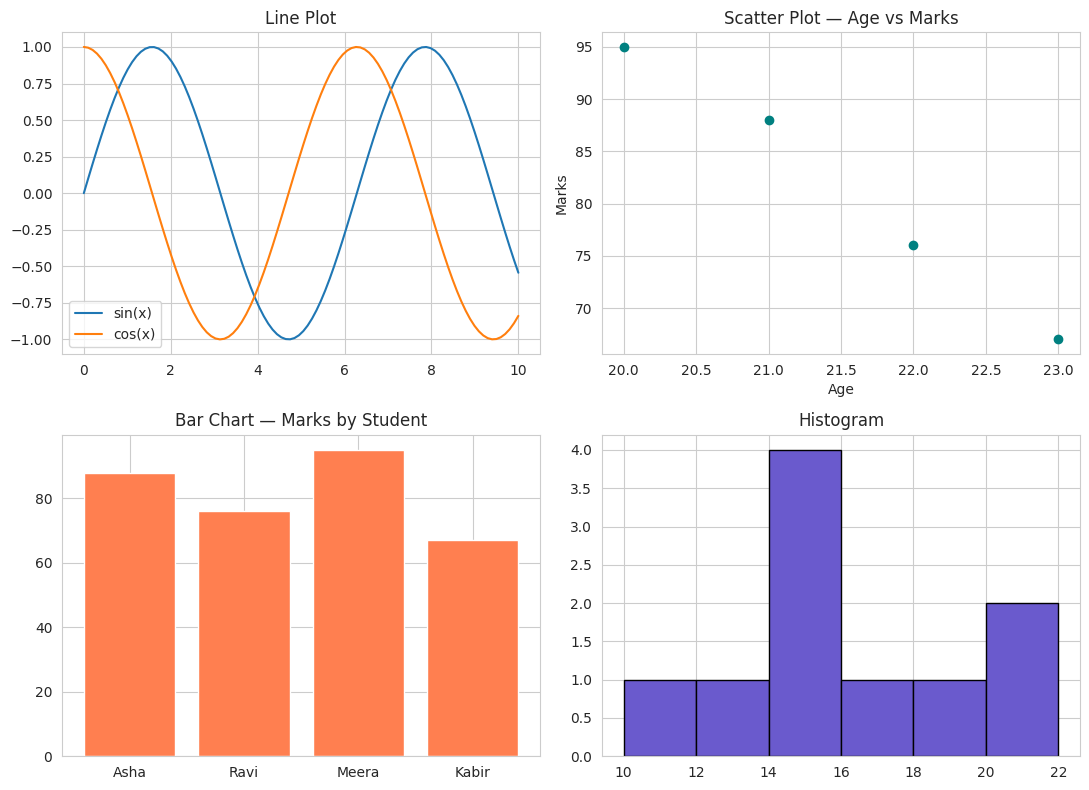

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Line plot
x = np.linspace(0, 10, 100)
axes[0, 0].plot(x, np.sin(x), label="sin(x)")
axes[0, 0].plot(x, np.cos(x), label="cos(x)")
axes[0, 0].set_title("Line Plot")
axes[0, 0].legend()

# Scatter plot
axes[0, 1].scatter(df["Age"], df["Marks"], c="teal")
axes[0, 1].set_title("Scatter Plot — Age vs Marks")
axes[0, 1].set_xlabel("Age"); axes[0, 1].set_ylabel("Marks")

# Bar chart
axes[1, 0].bar(df["Name"], df["Marks"], color="coral")
axes[1, 0].set_title("Bar Chart — Marks by Student")

# Histogram
axes[1, 1].hist(data, bins=6, color="slateblue", edgecolor="black")
axes[1, 1].set_title("Histogram")

plt.tight_layout()
plt.show()

## Part 5 — Scikit-learn: Core API Tour

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = LogisticRegression(max_iter=200).fit(X_train_s, y_train)
pred = clf.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=iris.target_names))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



This mirrors the standard Scikit-learn workflow: **load data → split → preprocess → fit → predict → evaluate**,
which is reused for every dataset below.

## Part 6 — Datasets: Loading & ML Task Identification

Five datasets are examined below. For each: load the data, identify the ML task type, perform EDA,
preprocess, select features, split, train a baseline model, and evaluate.

### 6.1 Iris Dataset — Multi-class Classification (Supervised)

In [13]:
iris = load_iris(as_frame=True)
iris_df = iris.frame
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))
print(iris_df.head())
print("\nShape:", iris_df.shape)
print("\nMissing values:\n", iris_df.isna().sum())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Shape: (150, 6)

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


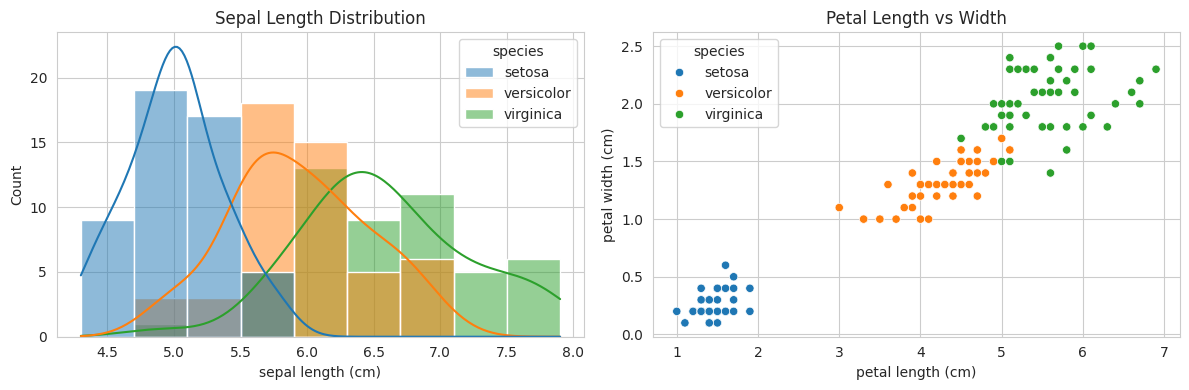

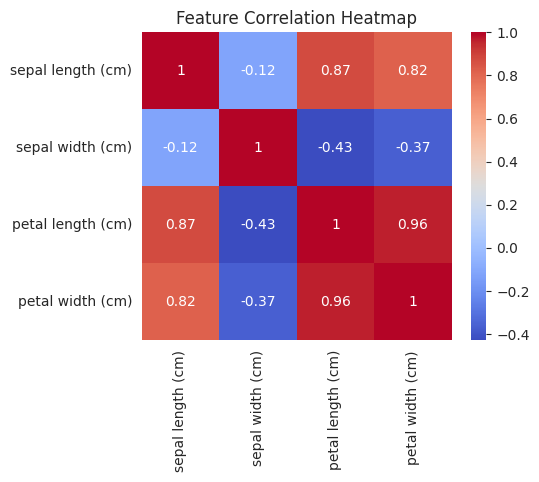

In [14]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=iris_df, x="sepal length (cm)", hue="species", kde=True, ax=axes[0])
axes[0].set_title("Sepal Length Distribution")
sns.scatterplot(data=iris_df, x="petal length (cm)", y="petal width (cm)", hue="species", ax=axes[1])
axes[1].set_title("Petal Length vs Width")
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(iris_df.iloc[:, :4].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# Feature selection — ANOVA F-test (SelectKBest)
from sklearn.feature_selection import SelectKBest, f_classif, chi2

X_iris, y_iris = iris.data, iris.target
selector = SelectKBest(score_func=f_classif, k=2).fit(X_iris, y_iris)
scores = pd.Series(selector.scores_, index=X_iris.columns).sort_values(ascending=False)
print("ANOVA F-scores:\n", scores)
print("\nTop 2 selected features:", X_iris.columns[selector.get_support()].tolist())

ANOVA F-scores:
 petal length (cm)    1180.161182
petal width (cm)      960.007147
sepal length (cm)     119.264502
sepal width (cm)       49.160040
dtype: float64

Top 2 selected features: ['petal length (cm)', 'petal width (cm)']


Accuracy: 0.9333333333333333


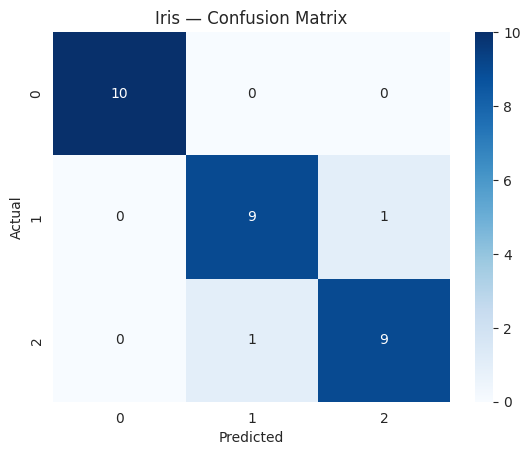

In [16]:
# Split, train, evaluate
Xtr, Xte, ytr, yte = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

model = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
pred = model.predict(Xte)
print("Accuracy:", accuracy_score(yte, pred))
sns.heatmap(confusion_matrix(yte, pred), annot=True, fmt="d", cmap="Blues")
plt.title("Iris — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

### 6.2 Loan Amount Prediction — Regression (Supervised)

Synthetic dataset mirroring the Kaggle *Loan Prediction* schema (income, credit history, loan term → loan amount). Replace with the real CSV if available.

In [17]:
rng = np.random.default_rng(1)
n = 500
loan_df = pd.DataFrame({
    "ApplicantIncome": rng.normal(5000, 1500, n).clip(1000),
    "CoapplicantIncome": rng.normal(1500, 800, n).clip(0),
    "LoanAmountTerm": rng.choice([120, 180, 240, 360], n),
    "CreditHistory": rng.choice([0, 1], n, p=[0.15, 0.85]),
    "Education": rng.choice(["Graduate", "Not Graduate"], n),
    "PropertyArea": rng.choice(["Urban", "Semiurban", "Rural"], n),
})
loan_df["LoanAmount"] = (0.02 * loan_df["ApplicantIncome"] + 0.015 * loan_df["CoapplicantIncome"]
                          + 20 * loan_df["CreditHistory"] + rng.normal(0, 15, n)).round(1)
# inject a few missing values, like a real-world dataset
for col in ["LoanAmount", "CreditHistory"]:
    loan_df.loc[rng.choice(n, 10, replace=False), col] = np.nan

print(loan_df.head())
print("\nMissing values:\n", loan_df.isna().sum())

   ApplicantIncome  CoapplicantIncome  LoanAmountTerm  CreditHistory  \
0      5518.376288         403.727803             180            0.0   
1      6232.427215        3240.478339             120            0.0   
2      5495.655614         390.069415             120            1.0   
3      3045.264153         637.983603             180            1.0   
4      6358.033800         539.309514             240            1.0   

      Education PropertyArea  LoanAmount  
0  Not Graduate        Urban        98.3  
1  Not Graduate        Urban       178.2  
2  Not Graduate        Urban       136.7  
3      Graduate    Semiurban        62.5  
4  Not Graduate    Semiurban       153.1  

Missing values:
 ApplicantIncome       0
CoapplicantIncome     0
LoanAmountTerm        0
CreditHistory        10
Education             0
PropertyArea          0
LoanAmount           10
dtype: int64


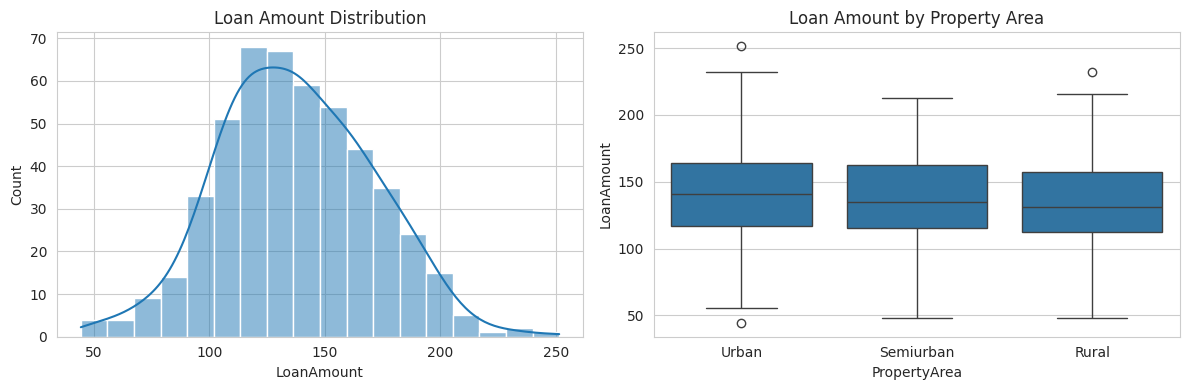

In [18]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df["LoanAmount"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Loan Amount Distribution")
sns.boxplot(data=loan_df, x="PropertyArea", y="LoanAmount", ax=axes[1])
axes[1].set_title("Loan Amount by Property Area")
plt.tight_layout(); plt.show()

In [19]:
# Preprocessing — impute, encode, scale
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

loan_clean = loan_df.dropna(subset=["LoanAmount"]).copy()
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmountTerm", "CreditHistory"]
cat_cols = ["Education", "PropertyArea"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

X_loan = loan_clean[num_cols + cat_cols]
y_loan = loan_clean["LoanAmount"]
Xtr, Xte, ytr, yte = train_test_split(X_loan, y_loan, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

reg_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())]).fit(Xtr, ytr)
pred = reg_pipe.predict(Xte)
print("MAE:", mean_absolute_error(yte, pred))
print("R2 score:", r2_score(yte, pred))

MAE: 10.365515419021234
R2 score: 0.8393612673168879


### 6.3 Predicting Diabetes — Classification (Supervised)

Using scikit-learn's built-in diabetes progression dataset, binarized around the median to frame it as the classic *diabetes risk classification* task (as in the Pima Indians dataset).

In [20]:
from sklearn.datasets import load_diabetes

diab = load_diabetes(as_frame=True)
diab_df = diab.frame.copy()
diab_df["Diabetic"] = (diab_df["target"] > diab_df["target"].median()).astype(int)
print(diab_df.head())
print("\nClass balance:\n", diab_df["Diabetic"].value_counts())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  Diabetic  
0 -0.002592  0.019907 -0.017646   151.0         1  
1 -0.039493 -0.068332 -0.092204    75.0         0  
2 -0.002592  0.002861 -0.025930   141.0         1  
3  0.034309  0.022688 -0.009362   206.0         1  
4 -0.002592 -0.031988 -0.046641   135.0         0  

Class balance:
 Diabetic
1    221
0    221
Name: count, dtype: int64


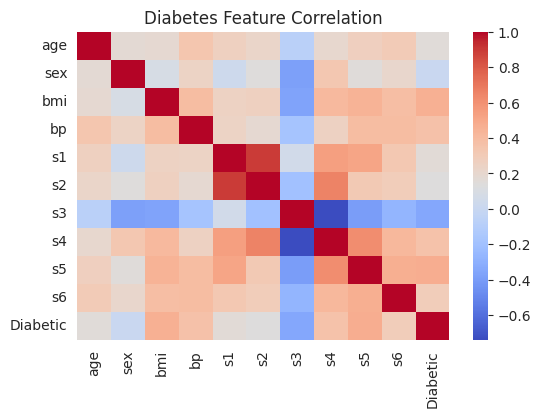

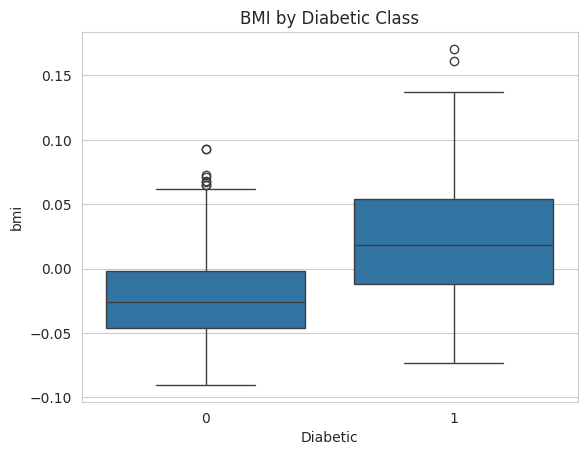

In [21]:
# EDA
plt.figure(figsize=(6, 4))
sns.heatmap(diab_df.drop(columns=["target"]).corr(), cmap="coolwarm", annot=False)
plt.title("Diabetes Feature Correlation")
plt.show()

sns.boxplot(data=diab_df, x="Diabetic", y="bmi")
plt.title("BMI by Diabetic Class"); plt.show()

In [22]:
# Feature selection — Chi-square needs non-negative features, so scale to [0,1] first
from sklearn.preprocessing import MinMaxScaler

X_d = diab_df.drop(columns=["target", "Diabetic"])
y_d = diab_df["Diabetic"]
X_d_pos = MinMaxScaler().fit_transform(X_d)
chi_scores, chi_p = chi2(X_d_pos, y_d)
print("Chi2 scores:\n", pd.Series(chi_scores, index=X_d.columns).sort_values(ascending=False))

Xtr, Xte, ytr, yte = train_test_split(X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42).fit(Xtr, ytr)
pred = clf.predict(Xte)
print("\nAccuracy:", accuracy_score(yte, pred))
print(classification_report(yte, pred))

Chi2 scores:
 bmi    9.010993
s5     6.868240
s4     6.313745
bp     4.874237
s3     4.147364
s6     2.236221
age    1.064828
s1     0.727213
s2     0.512967
sex    0.004831
dtype: float64

Accuracy: 0.7640449438202247
              precision    recall  f1-score   support

           0       0.82      0.69      0.75        45
           1       0.73      0.84      0.78        44

    accuracy                           0.76        89
   macro avg       0.77      0.76      0.76        89
weighted avg       0.77      0.76      0.76        89



### 6.4 Email Spam Classification — Classification (Supervised)

Synthetic bag-of-word-frequency features mirroring the UCI *Spambase* dataset schema.

In [23]:
rng = np.random.default_rng(2)
n = 600
# simulate word-frequency style features: spam mail has higher frequency of certain trigger words
spam_flag = rng.choice([0, 1], n, p=[0.6, 0.4])
spam_df = pd.DataFrame({
    "freq_free": np.where(spam_flag == 1, rng.gamma(2, 1.2, n), rng.gamma(0.5, 0.3, n)),
    "freq_win": np.where(spam_flag == 1, rng.gamma(2, 1.0, n), rng.gamma(0.3, 0.2, n)),
    "freq_offer": np.where(spam_flag == 1, rng.gamma(1.8, 1.1, n), rng.gamma(0.4, 0.25, n)),
    "capital_run_length": np.where(spam_flag == 1, rng.normal(35, 10, n), rng.normal(8, 4, n)).clip(1),
    "num_links": np.where(spam_flag == 1, rng.poisson(4, n), rng.poisson(1, n)),
    "is_spam": spam_flag,
})
print(spam_df.head())
print("\nClass balance:\n", spam_df["is_spam"].value_counts())

   freq_free      freq_win  freq_offer  capital_run_length  num_links  is_spam
0   0.005186  1.059091e-04    0.009559           10.560375          1        0
1   0.007124  2.267801e-02    0.000687            8.506613          0        0
2   5.255991  4.696247e+00    1.560650           46.052886          6        1
3   0.039815  1.567392e-10    0.082467           16.539829          1        0
4   2.854899  1.888972e+00    0.485142           46.061108          4        1

Class balance:
 is_spam
0    348
1    252
Name: count, dtype: int64


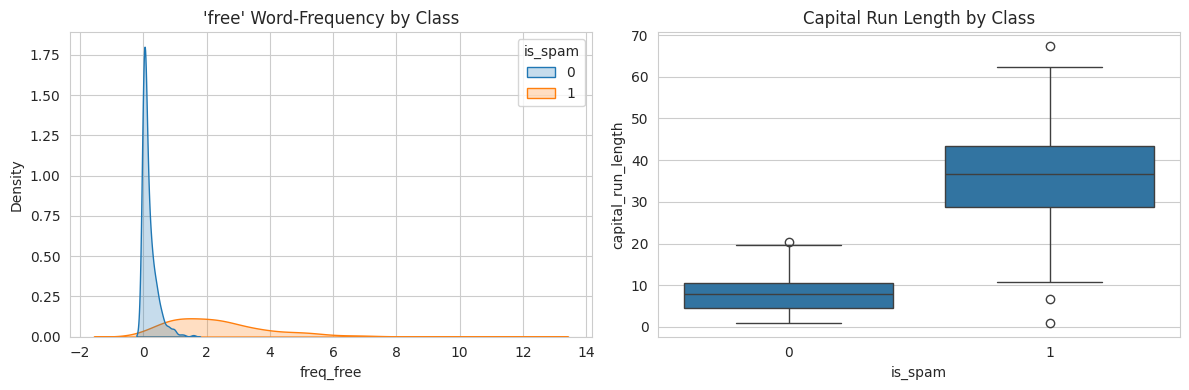

In [24]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=spam_df, x="freq_free", hue="is_spam", fill=True, ax=axes[0])
axes[0].set_title("'free' Word-Frequency by Class")
sns.boxplot(data=spam_df, x="is_spam", y="capital_run_length", ax=axes[1])
axes[1].set_title("Capital Run Length by Class")
plt.tight_layout(); plt.show()

In [25]:
# Feature selection, split, train, evaluate
X_s = spam_df.drop(columns=["is_spam"])
y_s = spam_df["is_spam"]

f_scores, _ = f_classif(X_s, y_s)
print("ANOVA F-scores:\n", pd.Series(f_scores, index=X_s.columns).sort_values(ascending=False))

Xtr, Xte, ytr, yte = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)
Xtr_s, Xte_s = StandardScaler().fit_transform(Xtr), StandardScaler().fit(Xtr).transform(Xte)

from sklearn.naive_bayes import GaussianNB
clf = GaussianNB().fit(Xtr_s, ytr)
pred = clf.predict(Xte_s)
print("\nAccuracy:", accuracy_score(yte, pred))
print(classification_report(yte, pred))

ANOVA F-scores:
 capital_run_length    2026.346089
num_links              630.929180
freq_offer             608.799155
freq_win               577.345968
freq_free              570.522262
dtype: float64

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        70
           1       0.93      1.00      0.96        50

    accuracy                           0.97       120
   macro avg       0.96      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



### 6.5 Handwritten Character Recognition (MNIST-style) — Classification (Supervised)

Using scikit-learn's built-in `load_digits` (8×8 handwritten digit images, 0–9) as a lightweight stand-in for the full 28×28 MNIST dataset.

Data shape: (1797, 64) | Image shape: (8, 8)
Classes: [0 1 2 3 4 5 6 7 8 9]


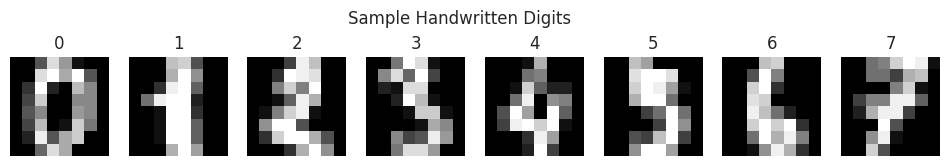

In [26]:
from sklearn.datasets import load_digits

digits = load_digits()
print("Data shape:", digits.data.shape, "| Image shape:", digits.images[0].shape)
print("Classes:", np.unique(digits.target))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(digits.target[i]); ax.axis("off")
plt.suptitle("Sample Handwritten Digits")
plt.show()

Accuracy: 0.95


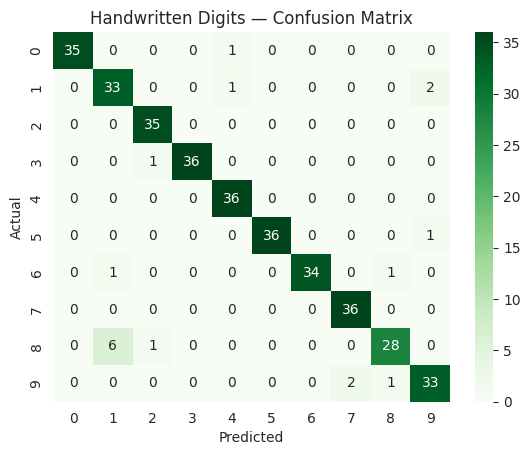

In [27]:
# Preprocessing (scale pixel intensities), split, train, evaluate
X_h, y_h = digits.data, digits.target
Xtr, Xte, ytr, yte = train_test_split(X_h, y_h, test_size=0.2, random_state=42, stratify=y_h)
Xtr_s = StandardScaler().fit_transform(Xtr)
Xte_s = StandardScaler().fit(Xtr).transform(Xte)

from sklearn.svm import SVC
clf = SVC(kernel="rbf", gamma=0.001).fit(Xtr_s, ytr)
pred = clf.predict(Xte_s)
print("Accuracy:", accuracy_score(yte, pred))

sns.heatmap(confusion_matrix(yte, pred), annot=True, fmt="d", cmap="Greens")
plt.title("Handwritten Digits — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

## Part 7 — Summary Table

In [28]:
summary = pd.DataFrame({
    "Dataset": ["Iris Dataset", "Loan Amount Prediction", "Predicting Diabetes",
                "Classification of Email Spam", "Handwritten Character Recognition / MNIST"],
    "Type of ML Task": ["Classification (Supervised)", "Regression (Supervised)",
                         "Classification (Supervised)", "Classification (Supervised)",
                         "Classification (Supervised)"],
    "Feature Selection Technique": ["ANOVA F-test (SelectKBest)", "Correlation / domain selection",
                                     "Chi-square test", "ANOVA F-test (SelectKBest)",
                                     "Variance/PCA (pixel intensities)"],
    "Suitable ML Algorithm": ["Decision Tree / Logistic Regression", "Linear Regression",
                               "Random Forest Classifier", "Naive Bayes / Logistic Regression",
                               "Support Vector Machine (SVM) / CNN"]
})
summary

,Dataset,Type of ML Task,Feature Selection Technique,Suitable ML Algorithm
0,Iris Dataset,Classification (Supervised),ANOVA F-test (SelectKBest),Decision Tree / Logistic Regression
1,Loan Amount Prediction,Regression (Supervised),Correlation / domain selection,Linear Regression
2,Predicting Diabetes,Classification (Supervised),Chi-square test,Random Forest Classifier
3,Classification of Email Spam,Classification (Supervised),ANOVA F-test (SelectKBest),Naive Bayes / Logistic Regression
4,Handwritten Character Recognition / MNIST,Classification (Supervised),Variance/PCA (pixel intensities),Support Vector Machine (SVM) / CNN


## Part 8 — Inference & Learning Outcomes

- **NumPy** provides fast, vectorized n-dimensional array operations that underlie all numerical
  computing in the ML stack (broadcasting, linear algebra, random sampling).
- **Pandas** offers labeled, tabular data structures (Series/DataFrame) with built-in tools for
  cleaning, grouping, and merging real-world datasets.
- **SciPy** extends NumPy with statistical tests, optimization, and linear-algebra routines needed
  for hypothesis testing and scientific computation.
- **Matplotlib/Seaborn** enable exploratory visualization (histograms, scatter plots, heatmaps, box
  plots) that reveal distribution shape, outliers, and feature relationships before modeling.
- **Scikit-learn** unifies the ML workflow — preprocessing, feature selection, model fitting, and
  evaluation — behind a consistent `fit`/`predict`/`transform` API.
- Across the five datasets, tasks ranged from **multi-class classification** (Iris, Digits, Spam,
  Diabetes) to **regression** (Loan Amount), showing how task type dictates the choice of algorithm,
  evaluation metric (accuracy/F1 vs. MAE/R²), and feature-selection method (ANOVA/Chi-square for
  classification, correlation-based methods for regression).
- Proper **preprocessing** (imputation, encoding, scaling) and **train/test splitting** were essential
  in every case to obtain reliable, generalizable performance estimates.
